# Chapter 5 - Credit Scoring

We will start out notebook by loading all datasets that might be useful for us.

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import statsmodels.api as sm
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection
from sklearn import feature_selection
from sklearn import pipeline
from sklearn import tree
from optbinning import BinningProcess
warnings.simplefilter(action='ignore', category=FutureWarning)

In [77]:
csvs_path = [rf'datasets/{name}.csv' for name in ['hmeq', 'lgd', 'ratings', 'mortgage']]
hmeq, lgd, ratings, mortgage = list(map(pd.read_csv, csvs_path))

## Judgmental versus statistical scoring

The judgmental approach is qualitative, expert-based and usually inspect the five Cs of the applicant and loan:

- Character measured the borrower's character and integrity (e.g., reputation, honesty, etc)

- Capital measures the difference between the borrower's assets and liabilities

- Collateral measures the collateral provided in case payment problems occur

- Capacity measures the borrower's ability to pay (e.g. job status, income, etc)

- Condition measures the bowwoer's circumstances (e.g. market conditions, competitive pressure, seasonal character, etc)

Statistical scoring on the other hand, are usually created based on scorecards and can be programmed and evaluated in an automated and fast way

## Techniques to build scorecards

### Logistic Regression

Logistic regression is a supervised machine learning algorithm in data science. It falls in the category of classification algorithm that predicts a discrete or categorical outcome. For example, we can use it to predict wether a loan is approved or not based on predictors. We can also use it to give a credit score to our costumers. Let's take the example given in the book. If we are modelling a binary default using linear regression we get a linear function, such as:

$D = \beta_0 + \beta_1 \times Age + \beta_2 \times Income + \beta_3 \times Employed$

But we know that it doesn't follow a normal distribution, instead, it follows a Bernoulli distribution with only two outcomes (0 or 1). But it's hard to limit a linear regression between 0 and 1 unless we have a bounding function like:

$f(z) = 1/(1+e^{(-z)})$

Let's take a look at the result of this function:

Text(0.5, 1.0, 'Sigmoid Function Plot')

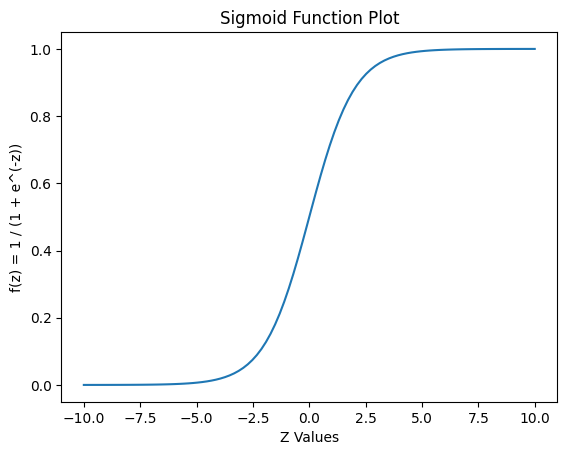

In [78]:
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))
sns.lineplot(x=z, y=sigmoid)
plt.xlabel("Z Values")
plt.ylabel("f(z) = 1 / (1 + e^(-z))")
plt.title("Sigmoid Function Plot")

We can notice that for every possible value of z, the function outputs a result between 0 and 1, and so, the result can be interpreted as a probability of default for a given input. 

So, if we combine the linear regression with this bounding function we can get our probability of default in function of the costumer Agr, Income and it's employment status. So we get something like:

Given:

$D = \beta_0 + \beta_1 \times Age + \beta_2 \times Income + \beta_3 \times Employed$

and 

$f(z) = 1/(1+e^{(-z)})$

then:

$f(D=1|Age, Income, Employed) = 1/(1+e^{-(\beta_0 + \beta_1 \times Age + \beta_2 \times Income + \beta_3 \times Employed)})$



The parameters of a logistic regression model are estimated using the idea of the maximum likelihood estimate(MLE) such as to maximize the probability of getting the sample at hand.
    - It tried different combinations of $\beta_n$ and for each combination verifies the likelihood of seeing the actual outcome in the data, given these parameters.

It's also important to take variable selection into account, as it aims to reduce the number of variables in a model, making it more concise and faster to train and evaluate. Like in a linear regression, for logistic regression we can use a statistical hypothesis test to verify whether the coefficient of a variable `i` is significantly different from 0 using the chi-square distribution with 1 degree of freedom.

If you want to read more about logistic regression here are some introductory resumes that can help:

- [IBM - Logistic Regression](https://www.ibm.com/think/topics/logistic-regression)
- [Speech and Language Processing. Daniel Jurafsky & James H. Martin - Chapter 5 (Draft)](https://web.stanford.edu/~jurafsky/slp3/5.pdf)

It's important to remember that in credit scoring, as well as some other cases, it's very important to be aware that statistical significance is only one evaluation creterion to be considered in variable selection. Interpretability is very important, the variables used must make logical sense and the sign must be the same as the antecipated. This helps not only in understading the model but explaining how it works and selling it's value.

It's also important to consider operational efficiency, some variables may be too costly to obtain and the difference in results (with or without it) may not be worth the value it adds to the model; as well as legal issues as you might not be allowed to dicriminate based on gender, age, beliefs and so on, which makes these variables not viable in the model, even if they have statistical significance.

#### Build Logistic Regression Models in Python

Like in the book, let's start by selection our variables and creating dummies with values 0 or 1 and adding these to our data

In [79]:
reg_input = hmeq[['BAD', 'CLAGE', 'CLNO', 'DEBTINC', 'DELINQ', 'DEROG', 'JOB', 'LOAN', 'MORTDUE', 'NINQ', 'REASON', 'VALUE', 'YOJ']]

In [80]:
dummies = pd.get_dummies(reg_input.select_dtypes(exclude=[np.number]), dtype=int)
not_dummies = reg_input.select_dtypes(include=[np.number])
reg_input = pd.concat([not_dummies, dummies], axis = 1)
reg_input = reg_input.dropna()

In [81]:
X = reg_input.loc[:, reg_input.columns != 'BAD']
Y = reg_input['BAD']

# Remember we should split our data into training and testing at least
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, Y, test_size=0.2, random_state=10)


As far as I know we don't have the exact same feature selection in python, so we are left with a few options like:

    - program something similar
    - use something nearly equivalent

Let's try it both ways:

First, let's try build a similar function. But why build it? Because we can't specify p-values for `sklearn`, so what we do with `statsmodels` is run logistic with each variable and check it's p-value to decide with variable to add and which variable to remove.

In [82]:
def stepwise_selection(X, y, threshold_in=0.05, threshold_out=0.01, verbose=True, iterlimit=1000):
    included = []
    itercount = 0
    while True:
        changed = False
        itercount +=1
        # forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(dtype=float, index=excluded)
        for col in excluded:
            model = sm.Logit(y, sm.add_constant(X[included + [col]])).fit(disp=False)
            new_pval[col] = model.pvalues[col]
        if not new_pval.empty:
            best_pval = new_pval.min()
            if best_pval < threshold_in:
                best_feature = new_pval.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print(f"Add {best_feature:>30} with p-value {best_pval:.6f}")
        # backward step
        if included:
            model = sm.Logit(y, sm.add_constant(X[included])).fit(disp=False)
            pvals = model.pvalues.iloc[1:]  # exclude intercept
            worst_pval = pvals.max()
            if worst_pval > threshold_out:
                worst_feature = pvals.idxmax()
                included.remove(worst_feature)
                changed = True
                if verbose:
                    print(f"Drop {worst_feature:>30} with p-value {worst_pval:.6f}")
        if (not changed)|(itercount>iterlimit):
            break
    return included

To run this function, let's remember it's important to add constant to `statsmodels` if we want it to fit a model with intercept, instead it will use `b=0` instead of calculating it's value (equivalent to `fit_intercept=False` in `scikit-learn`).

In [83]:
X_sm = sm.add_constant(X_train)
stpwise_selected_features = stepwise_selection(X_sm, y_train, threshold_in=0.05, threshold_out=0.02, verbose=False, iterlimit=100)
stpwise_model = linear_model.LogisticRegression(max_iter=1000)
stpwise_model.fit(X_sm[stpwise_selected_features[1:]], y_train)

print("Let's check the variables and it's coefficients:")
for name, coef in zip(sorted(stpwise_selected_features), stpwise_model.coef_[0]):
    print(f"Variable:{name:>30} | Coef: {coef:.4f}")

Let's check the variables and it's coefficients:
Variable:                         CLAGE | Coef: 0.7952
Variable:                          CLNO | Coef: 0.0973
Variable:                       DEBTINC | Coef: 0.7837
Variable:                        DELINQ | Coef: -0.0063
Variable:                         DEROG | Coef: -0.5874
Variable:                    JOB_Office | Coef: -0.0243
Variable:                     JOB_Sales | Coef: 0.1117
Variable:                          NINQ | Coef: 0.9635


Now, if we want a more specific implementation without using `statsmodels` to mimic SAS, we can use something like [`RFE`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html) (Recursive Feature Elimination) to rank variables based on model impact.

Since it's a binary classification problem let's go with `liblinear`. Feel free to try different solvers.

In [84]:
rfe_model = linear_model.LogisticRegression(max_iter=2000, solver='liblinear')
# We could also add a preprocess step in the pipeline to deal with the normalization of categorical variables.
rfe_pipeline = pipeline.Pipeline(steps=[('select', feature_selection.RFE(rfe_model, n_features_to_select=15)),('model',rfe_model)])
rfe_pipeline.fit(X_train, y_train)

rfe_selected_features = X_train.columns[rfe_pipeline.named_steps['select'].support_].to_list()

print("Let's check the variables:")
for name in rfe_selected_features:
    print(f"Variable:{name:>30}")

Let's check the variables:
Variable:                         CLAGE
Variable:                          CLNO
Variable:                       DEBTINC
Variable:                        DELINQ
Variable:                         DEROG
Variable:                          NINQ
Variable:                           YOJ
Variable:                       JOB_Mgr
Variable:                    JOB_Office
Variable:                     JOB_Other
Variable:                   JOB_ProfExe
Variable:                     JOB_Sales
Variable:                      JOB_Self
Variable:                REASON_DebtCon
Variable:                REASON_HomeImp


As in the Book, the final variables were CLAGE, CLNO, DEBTINC, DELINQ, DEROG, JOB (Office and Sale) and NINQ and the variables LOAN, MORTDUE, VALUE, REASON and YOJ have no impact in the default risk. However when we use the RFE, we end up with some other variables. Let's check the ROC of both models.

As we are following the book, we will enter into details on ROC on the validation chapter as well, but a simple description of it would be that the curve visually represents the trade-off between true positive rate and false positive rate at various classification thresholds, while the AUC quantifies the model's ability to destinguise between classes. In other words, it's a powerful tool for evaluation binary classification models since it tells us how good (correcly) or model is classifying our data.

First, let's try our second model, using RFE. We obtain a ROC AUC Score of 0.80% which is really good.

ROC AUC Score: 0.8018


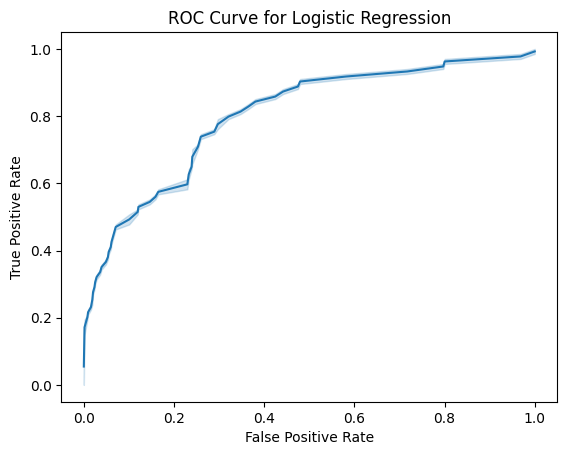

In [85]:
y_prob = rfe_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_prob)
roc_auc = metrics.auc(fpr, tpr)

auc_score = metrics.roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

sns.lineplot(x=fpr, y=tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.show()

Let's check the other model, more similar to the book. We get a score of 0.81, which is very good (being 1 a perfect separation)

ROC AUC Score: 0.8152


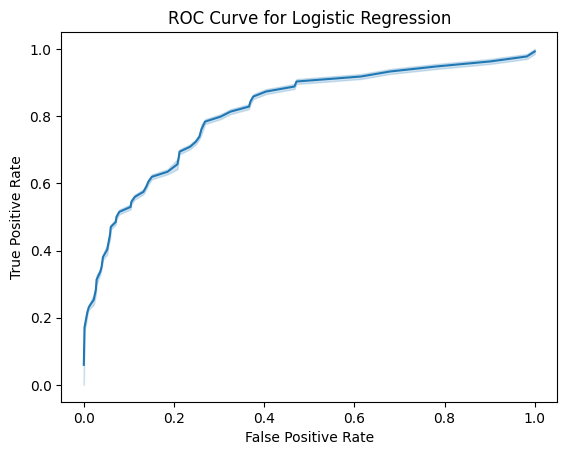

In [86]:
y_prob = stpwise_model.predict_proba(X_test[stpwise_selected_features[1:]])[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_prob)
roc_auc = metrics.auc(fpr, tpr)

auc_score = metrics.roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

sns.lineplot(x=fpr, y=tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.show()

#### Using Logistic Regression for Credit Scoring

Logistic regression is a very popular and powerful classification technique due to its simplicity and good performance. Just as linear regression, once the parameters have been estimated, it can evaluated in a simple way, which contributes to it's operation efficiency as well as makes it easier to explain to your colleagues and superiors, even if they have low to none statistical knowledge.

Based on the regression results, we could, for example, build a credit score which, based on attributes intervals would give us points, that summed up would give us the total credit score which would tell us if we should accept or reject that costumer. Scorecards are very easy to work with, especially when interpretability is a key concern.

We can simulate SAS building scorecards in python through the following (we will be using the regression most similar to the book, which gave us the highest ROC):

In [87]:
intercept = stpwise_model.intercept_[0]
coefs = stpwise_model.coef_[0]
scorecard = pd.DataFrame({'Feature':[*stpwise_selected_features[1:], 'Intercept'], 'Coefficient': [*coefs, intercept]})
scorecard

,Feature,Coefficient
0,DELINQ,0.795171
1,DEBTINC,0.097309
2,DEROG,0.783691
3,CLAGE,-0.006284
4,JOB_Office,-0.587428
5,CLNO,-0.024304
6,NINQ,0.111682
7,JOB_Sales,0.963528
8,Intercept,-4.932014


Now we must define some parameters to the scoreboard. Let's use the same as in the book

In [88]:
PDO = 20
base_odds = 50 # 50:1 odds at base score
base_score = 600
factor = PDO / np.log(2)
offset = base_score - factor * np.log(base_odds)
scorecard['Score_Contribution'] = -scorecard['Coefficient'] * factor
scorecard['Rounded_Score'] = scorecard['Score_Contribution'].round(0).astype(int)
scorecard

,Feature,Coefficient,Score_Contribution,Rounded_Score
0,DELINQ,0.795171,-22.943776,-23
1,DEBTINC,0.097309,-2.807736,-3
2,DEROG,0.783691,-22.612532,-23
3,CLAGE,-0.006284,0.181317,0
4,JOB_Office,-0.587428,16.949603,17
5,CLNO,-0.024304,0.701254,1
6,NINQ,0.111682,-3.222467,-3
7,JOB_Sales,0.963528,-27.801534,-28
8,Intercept,-4.932014,142.307840,142


For a single client, we have:

In [89]:
y_prob = stpwise_model.predict_proba(X[stpwise_selected_features[1:]])[:, 1]
log_odds = np.log(y_prob / (1 - y_prob))

# Compute score
scores = offset - factor * log_odds
scores = scores.round(0).astype(int)


Now, if we want to do it by bins, like it's the more usually seen way, then we have:

In [90]:
def build_scorecard_table(binning_process, model, factor=20 / np.log(2), offset=600 - (20 / np.log(2)) * np.log(50)):

    scorecard_tables = []
    intercept_score = offset - factor * model.intercept_[0]

    for i, var in enumerate(binning_process.variable_names):
        binning = binning_process.get_binned_variable(var)
        bin_table = binning.binning_table.build(add_totals=False)

        # Flatten column names if MultiIndex
        if isinstance(bin_table.columns, pd.MultiIndex):
            bin_table.columns = ['_'.join(col).strip() for col in bin_table.columns.values]

        # Try to find WOE column
        woe_col_candidates = [col for col in bin_table.columns if "WOE" in col.upper()]
        if not woe_col_candidates:
            raise ValueError(f"No WOE column found in binning table for variable '{var}'")
        woe_col = woe_col_candidates[0]

        if "Bin" in bin_table.columns:
            bin_labels = bin_table["Bin"].astype(str).values
        else:
            # fallback to index if needed
            bin_labels = bin_table.index.astype(str)

        # Prepare score contribution
        woe_values = np.array(bin_table[woe_col], dtype=float)  # Ensure float array
        coef = model.coef_[0][i]
        scores = (-coef * woe_values * factor).round(0)

        df = pd.DataFrame({
            "Variable": var,
            "Bin": bin_labels,
            "WOE": woe_values.round(4),
            "Coefficient": round(coef, 4),
            "Score": scores.astype(int)
        })

        scorecard_tables.append(df)

    # Intercept score
    intercept_df = pd.DataFrame([{
        "Variable": "Intercept",
        "Bin": "All",
        "WOE": "",
        "Coefficient": round(model.intercept_[0], 4),
        "Score": round(intercept_score)
    }])

    # Combine everything
    scorecard_df = pd.concat([intercept_df] + scorecard_tables, axis=0).reset_index(drop=True)
    return scorecard_df


In [91]:
binning_process = BinningProcess(variable_names=stpwise_selected_features[1:],
                                 categorical_variables=['JOB_Office', 'JOB_Sales'],
                                 verbose=True)

# Fit binning process
binning_process.fit(X[stpwise_selected_features[1:]], Y)

2025-07-06 11:33:36,685 | INFO : Binning process started.
2025-07-06 11:33:36,686 | INFO : Options: check parameters.
2025-07-06 11:33:36,687 | INFO : Dataset: number of samples: 3515.
2025-07-06 11:33:36,687 | INFO : Dataset: number of variables: 8.
2025-07-06 11:33:36,688 | INFO : Options: number of jobs (cores): 1.
2025-07-06 11:33:36,688 | INFO : Binning variable (0 / 8): DELINQ.
2025-07-06 11:33:36,700 | INFO : Binning variable (1 / 8): DEBTINC.
2025-07-06 11:33:36,763 | INFO : Binning variable (2 / 8): DEROG.
2025-07-06 11:33:36,778 | INFO : Binning variable (3 / 8): CLAGE.
2025-07-06 11:33:36,921 | INFO : Binning variable (4 / 8): JOB_Office.
2025-07-06 11:33:36,936 | INFO : Binning variable (5 / 8): CLNO.
2025-07-06 11:33:36,998 | INFO : Binning variable (6 / 8): NINQ.
2025-07-06 11:33:37,014 | INFO : Binning variable (7 / 8): JOB_Sales.
2025-07-06 11:33:37,016 | INFO : Binning process variable selection...
2025-07-06 11:33:37,073 | INFO : Binning process terminated. Time: 0.38

BinningProcess(categorical_variables=['JOB_Office', 'JOB_Sales'],
               variable_names=['DELINQ', 'DEBTINC', 'DEROG', 'CLAGE',
                               'JOB_Office', 'CLNO', 'NINQ', 'JOB_Sales'],
               verbose=True)

In [92]:
scorecard_df = build_scorecard_table(binning_process, stpwise_model)
scorecard_df

,Variable,Bin,WOE,Coefficient,Score
0,Intercept,All,,-4.9320,629
1,DELINQ,"(-inf, 0.50)",0.3193,0.7952,-7
2,DELINQ,"[0.50, 1.50)",-0.4572,0.7952,10
3,DELINQ,"[1.50, inf)",-1.6117,0.7952,37
4,DELINQ,Special,0.0,0.7952,0
5,DELINQ,Missing,0.0,0.7952,0
6,DEBTINC,"(-inf, 30.15)",0.6114,0.0973,-2
7,DEBTINC,"[30.15, 34.49)",0.3884,0.0973,-1
8,DEBTINC,"[34.49, 40.35)",0.2761,0.0973,-1
9,DEBTINC,"[40.35, 42.80)",-0.0424,0.0973,0


### Decision Trees

Decision trees are non-parametric supervised learning algorithms used for both classification and regresson tasks. It has a hierarchical tree structure, which consists of a root node, branches, internal nodes and leaf nodes (as described by [IBM](https://www.ibm.com/think/topics/decision-trees)). Each node will have a testing condition that will end up leading to a result. The book brings the following algorithms as the most commonly used for constructing decisions trees:
- C4.5
- CART
- CHAID
They differ in how they create the splitting decision (which variable to split and at what value), when to stop adding new nodes to the tree and what class to assign to a leaf node, for example, in the case we've been studying, we could choose to have the end node as good or bad.

Decision trees are heavely based on the concept of entropy, which measures the impurity of the sample values, and is defined by the following formula:

$Entropy(S) = -\sum_{c\epsilon C}p(c)log_2p(c)$

Where $p(c)$ is the proporcion of data points that belongs to class $c$ to the number of total data points in the set ($S$). It's value is limited between 0 and 1. We have 0 when all of our data belongs to a single class (there's no impurity) and we have 1 when half of our data belongs to each class (when there total impurity, that is, there's no dominating population). The algorithm searchs for the attributes with the smalles amount of entropy.

After a split, we will calculate the entropy of the new groups, the difference in entropy before and after a split on a given attribute is called information gain, that is to say, how much information can I gain by having split this group? 

It is usually represented by:

$Information Gain (S,a) = Entropy(S) - \sum_{v\epsilon calues(a)} \frac{|S_v|}{|S|} Entropy(S_v)$

Let's take an example (the same as in the book). Let's say we have tree nodes, a top node that breaks into two other nodes, one to the left and one to the right, and their entropy is as follows:
- We have a total of 800 costumers, where 400 are bad and 400 are good and we will separate them according to their age. One group will be below 30 years and the other above 30 years.
- top node = $-1/2 \times log_2(1/2)-1/2 \times log_2(1/2) = 1$ (which means that we have two groups, good and bad, evenly destributed)
- Now we have a left node with 200 good costumers and 400 bad costumers and a right node with 200 good costumers.
- left node = $-1/3 \times log_2(1/3) - 2/3 \times log_2(2/3) = 0.91$ because we have a group that holds 2/3 of the population (400 bads) and a group that holds 1/3 of the population (200 good ones)
 - right node = $-1 \times log_2(1) - 0 \times log_2(0) = 0$ because we only have one group that holds all the population of this node(the 200 good ones)

 As we look at the information gain formula, it might seem complex, but in truth, it's only the difference between the entropy we had and weighted sum of the new entropies. Which in this case give us:
 - $Gain = 1 - (600/800)\times 0.91 - (200/800) \times 0 = 0.32$
 
The greater the value of the information gain, the more valuable the split, and so, the algorithm takes a greedy stategy by picking the one with the biggest gain. Once a decision has been made the procedure continues in a recursive way, adding new splits until a stopping decision is made (and this is a very important step, otherwise our model can overfit).


#### Stopping Decision

So, when to stop? That is a very important question, because if we have too much nodes we will have a perfect fit for our data, but we will lose the ability to generalise the information learned and so, we would have an overfitting problem, which is one of the disvantages of this model (it's quite prone to overfitting). We want a tree able to correcly model the trend in the data and performs well in unseen data. To try avoiding this, we can separate our data intro training and testing to checkout the tree performance on unseen data and also do some pre-pruning (halting tree growth when theres insuffiencient data) and post-pruning (removing subtrees with inadequate data after tree construction).



#### Example

As far as I've read, there's not an example on decision trees on the book. I believe it's because, as the author says, logistic regression is the most popular scorecard construction technique used in industry because for decision trees, every leaf node corresponds to a particular score (the proportion of goods in the leaf node) and so, only a limited set of score values is provided, which may not be sufficient to provide a fine and granular distinction between obligators in terms of default risk and this make them quite inferior in building scorecards.

Tut it's to fun of an implementation to pass on so we're going to try making a simple and fast one. We will be using the same data as we've used before. Let's also make it so we're going to use the tree with selected features and without selection and compare the results



Accuracy without selection: 0.9288762446657184
ROC AUC Score: 0.7741


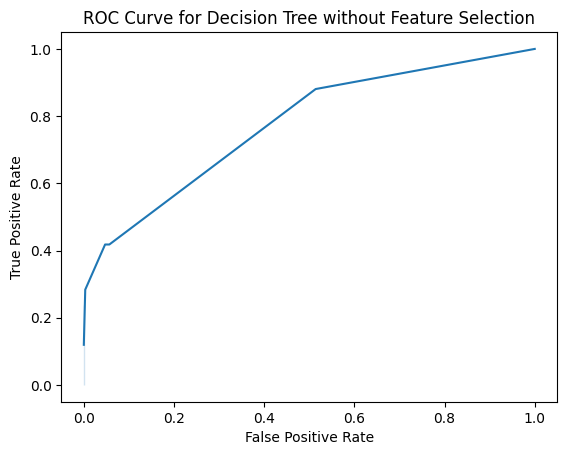

In [93]:
clf = tree.DecisionTreeClassifier(criterion="entropy", max_depth=3)
clf = clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy without selection:",metrics.accuracy_score(y_test, y_pred))

y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_prob)
roc_auc = metrics.auc(fpr, tpr)

auc_score = metrics.roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

sns.lineplot(x=fpr, y=tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Decision Tree without Feature Selection")
plt.show()



Accuracy without selection: 0.9288762446657184
ROC AUC Score: 0.7741


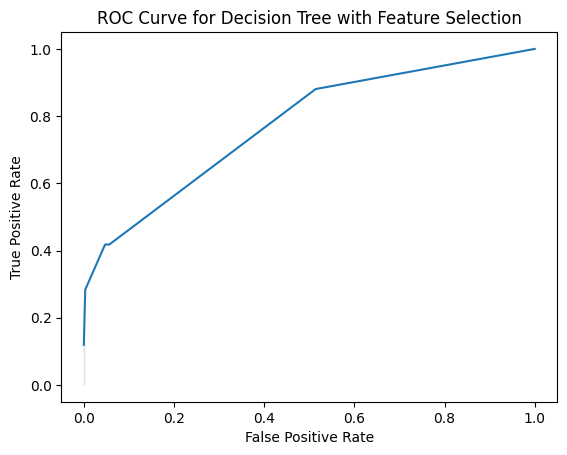

In [94]:
clf_sel = tree.DecisionTreeClassifier(criterion="entropy", max_depth=3)
clf_sel = clf_sel.fit(X_train[stpwise_selected_features[1:]],y_train)
y_pred = clf_sel.predict(X_test[stpwise_selected_features[1:]])
print("Accuracy without selection:",metrics.accuracy_score(y_test, y_pred))

y_prob = clf_sel.predict_proba(X_test[stpwise_selected_features[1:]])[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_prob)
roc_auc = metrics.auc(fpr, tpr)

auc_score = metrics.roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

sns.lineplot(x=fpr, y=tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Decision Tree with Feature Selection")
plt.show()

We can also visualize these trees by using some packages. Lets try it

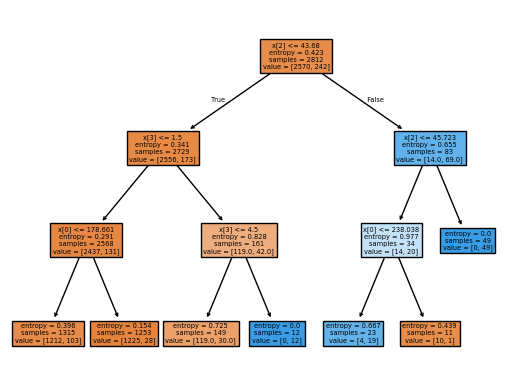

In [95]:
annotations = tree.plot_tree(clf, filled = True)

We could also try using Grid Search to optimize our tree. Let's give it a quick try. As there wasn't much of a difference between using the filtered and unfiltered columns, let's go with the unfiltered ones.

In [96]:
# Define the parameter grid
param_grid = {
    'max_depth': [2, 4, 6, 8],
    'min_samples_split': [2, 3, 4, 8],
    'min_samples_leaf': [2, 3, 4],
    'criterion': ['gini', 'entropy', 'log_loss']
}

# Create a Decision Tree classifier
clf = tree.DecisionTreeClassifier(random_state=10)

# Perform Grid Search cross-validation
grid_search = model_selection.GridSearchCV(clf, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

# Get the best parameters and model
best_params = grid_search.best_params_
best_score = grid_search.best_score_
best_dtree = grid_search.best_estimator_

print(f'Chosen parameters, with a score of {float(best_score)} are')
for y,x in zip(best_params.keys(), best_params.values()):
    print(f'\t{y}:{x}')

Chosen parameters, with a score of 0.7847996737605548 are
	criterion:entropy
	max_depth:8
	min_samples_leaf:2
	min_samples_split:2


d:\projects\cra_mtae_sas_in_py\.venv\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Accuracy: 0.9331436699857752
ROC AUC Score: 0.7479


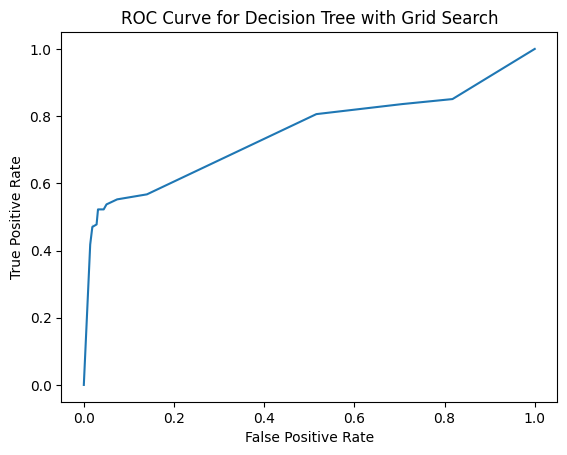

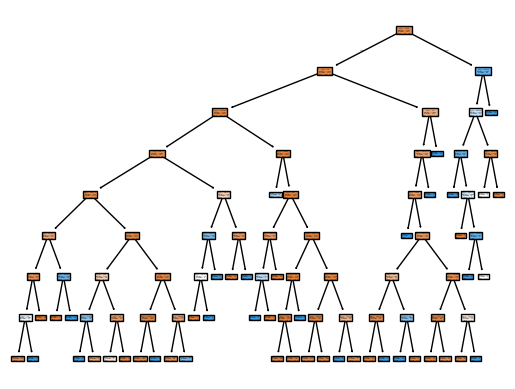

In [97]:
y_pred = best_dtree.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

y_prob = best_dtree.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_prob)
roc_auc = metrics.auc(fpr, tpr)

auc_score = metrics.roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {auc_score:.4f}")

sns.lineplot(x=fpr, y=tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Decision Tree with Grid Search")
plt.show()

annotations = tree.plot_tree(best_dtree, filled = True)

### Credit Scoring for Retail Exposures

The tree key statistical approaches for credit scoring in retail portfolios are:
- application scoring
- behaviour scoring
- dynamic scoring

All three are based on historical data and in the book we will focus, at least for now in scorecards. Let's check how it works in each approach.

#### Aplication Scoring

The idea is to come up with a credit score that reflects the default risk of a costumer at the moment of loan application. It helps decide wether the loan should be accepted or rejected. The definition of default varies, although it's usually 90 days in payment arrears.

After deciding the definition of default, the next step is to identify the information that can be used to predict said default. We can have application variables and bureau variables.
    - Application variables are information provided to the bank by the applicant upon loan application. Popular examples are age, gender, marital status, income, time at residence, number of years as client, number of products internally, and much others (if we already have this costumer as a client we usually have more information about it). These are the information internally available to the bank, which are complemented by bureau variables.
    - Credit bureau are organizations that assemble and aggregates credit information from various financial instituions or banks (in Brazil, for example, we have Serasa, Boa Vista, SPC and Quod as the most famous ones). It can collect both positive and negative information, depending upon the country in which it operates (You probably heard about ["cadastro positivo"](https://www.serasa.com.br/cadastro-positivo/) in Brazil, which was implemented in 2019).
        - They usually provide two sources of information: Raw data, such as number of previous delinquencies, total amount of credit outstading, previous delinquency history, and others; and bureau credit scores (which use the raw data).

When building an scorecard you are taking two snapshots of costumer behavior. The first is taken at loan origination where you gather both the application and credit bureau data. This is used to predict default. The second snapshot is taken at some later point during the loan at which the default behavior will be determined. Many firms usually do so in around 18 months, as there are studies that shows that the majority of costomers who defaults do so in the first 18 months.

It's important to remember that probability of default are more precise than application scoring (although it can have a related probability of default, it's usually an interval or it's mean).

#### Behavioral Scoring

In this case, one analyzes the behavior of existing credit customers. Usually 12 months are taken to measure and quantify all the information that will be used as predictors to predict the next 12 months to determine the default status. As we will have a long period of data, aggregate functions need to be used and trend variables can be calculated.

It's also important to take into account the issue with migrating from application to behaviour score, as a sudden move can cause fluctuations. Many banks work with a transition period of about six months during which a weighted combation of both scores is used, and thus, the transition score becomes:

$\alpha \times AS + (1-\alpha) \times BS$

With $\alpha$ decreasing as time passes

#### Dynamic Scoring

Unlike application and Behavioral scoring which asses risk for a fixed time horizon, in dynamic scoring, risk assessments will be provided for any future moment in time. Basically, these techniques allow us to model not jsut if a borrower will default, but also when. The outcomes of these models not only are useful for credit risk assessment but also can be used to model custumer lifetime value (CLV), for example.

#### Reject inference

The problem of reject inference refers to the fact that data available to build application scorecards concerns only the past accepts and not the rejects since we don't know their default or non default behaviour, as they were rejected. If we do not include the rejects in the application scorecard development process, we will be creating a bias, which should be avoided, and so, various methods for handling these rejects have been suggested. Below we will list some options (the same as the listed in the book).

    - All rejects can be classified as bad payers. It's a conservative approach since we are assuming the worst possible outcome, but as so, the bad rate sample will be too high.

    - Another option is to build a score card using the accepts only and then use this scorecard to classificate the rejects. These rejects are then ranked according to their score and classified as defaulters accoring to a bad rate definition. This data is then added to the accepts and a new scorecard is built.

    - We can also use the model above, but instead of using a bad rate for the global population, we can apply a bad rate for each score group.

    - Another option, using fuzzy augmentation is to build a model on the accepts and attribute a probability of being good to the rejects. Every reject is then duplicated, with one data multiplied by their probability of being good and another by their probability of being bad.

    - Another option is the nearest neighbor method. For every reject, look at the k most similar accepts in the Euclidean snse. You can then assign the most common class among those nearest neighbors to the reject.

    - A controversial approach to do the reject inference is granting credit to all costumers, including the reject, during a specific period of time. The idea is to grand credit to some but not all rejects by evaluating the trade-off between the cost of granting credit to rejects and the benefit of obtaining a better scoring model.
    
    -Credit bureau inference can also be used. The idea is to ask the bureau if some past rejects received a credit elsewhere and what was their performance at these other financial institutions. The problem that might be faced here is that the credit recieved in other banks may be udner other conditions that you may not know, making the comparison not stricly fair.

### Credit scoring for nonretail exposures

#### Prediction Approach

Assumes that there is historical data vailable about the obligators and their default status. This data can then be analyzed by statistical techniques to predict default behavior. A well-known model for bankruptcy prediction is the Altman z-model for manufacturing firms where the z-score is a linear combination of five accounting ratios. A higher z score reflects a healthier firm with lower bankruptcy risk. It's important to notice that the z-score model has been built using US corprates and care should be taken when applying it to other countries.

#### Expert Based Approach

In case of lacking data, expert-based approeach is used in nonretail credit risk modeling.

#### Agency Rating Approach

If no other option is available (or to complement the data available), rating agencies can be used, as they score mostly any nonretail exposure.

#### Shadow Ratings Approach

The idea is to start with a data set with ratings and characteristics for a particular set of obligors and then map the influence of these variables in the rating. The idea is to obtain a "white box" understandable model that clearly indicates how the various characteristics of an obligor contribute to the rating.